# Quantum computing on a laptop, using a real quantum computer

**Short answer: yes, and yes.**

Nobody has an actual gate-based quantum processor sitting inside a laptop — real qubits (superconducting circuits, trapped ions, etc.) need dilution refrigerators, vacuum chambers, or precision optics. What you *can* do on a laptop is write and run a normal Jupyter notebook that:

1. Builds quantum circuits with a Python SDK (this notebook uses **Qiskit**),
2. Runs them instantly on a local **simulator** for development/debugging, and
3. Submits the *exact same circuit* over the internet to a **real quantum chip** sitting in an IBM datacenter, then pulls the measurement results back into your notebook.

That's it — that is what "using a real quantum computer from your laptop" means in practice for essentially every academic paper that reports hardware results today.

**Free real-hardware access exists right now.** IBM Quantum's free "Open Plan" gives every registered user real QPU time (their current top-end 127+ qubit "Eagle"/"Heron" processors) — the documented allowance is **10 minutes of QPU time per rolling 28-day window**, and as of a March 2026 promotion, existing Open Plan users can opt in to an **extra 180 minutes over 12 months**. Ten minutes sounds tiny, but a single shallow circuit with a few thousand shots typically takes well under a second of actual QPU time — the rest of a "job" is queueing, which is free. So 10 minutes/month is enough for dozens of small real experiments like the ones below. (Sources at the bottom.)

Other free/low-cost routes to real hardware: Amazon Braket and Azure Quantum offer pay-per-shot access to IonQ/Rigetti/Quantinuum devices (small free credits for new accounts, not an ongoing free tier); IBM is the most reliably free option as of 2026.

This notebook runs entirely on the **local simulator** (`qiskit-aer`) so it works offline with no account — every plot and number below is a real computed result, not a mockup. Section 5 shows, with runnable code, exactly what changes to point the same circuits at a real IBM QPU once you have a (free) IBM Quantum account and API token.

---

**What counts as a genuine "basic science result" on today's noisy, small quantum computers?** The demos below are chosen because each one *is* an actual physics result (not just a "toy program"):

- **Entanglement generation** (Bell/GHZ states) — directly measuring the defining phenomenon of quantum mechanics.
- **A Bell/CHSH inequality test** — an experimental test of local realism; violating the bound of 2 is a real statement about nature, first done by Aspect et al. in the 1980s with photons, now routinely reproduced on cloud QPUs by students.
- **A variational quantum eigensolver (VQE)** for a spin model (transverse-field Ising model) — a real condensed-matter physics calculation: finding a ground-state energy and watching a quantum phase transition signature emerge, which is the same technique used in published quantum chemistry/materials papers.

Section 6 lists further experiments that are within reach of free hardware time.


In [1]:
# Environment check — this notebook only needs qiskit + qiskit-aer + numpy/scipy/matplotlib,
# all of which run locally with no account or internet connection required.
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.visualization import plot_histogram
from scipy.optimize import minimize
import qiskit, qiskit_aer

print("qiskit      :", qiskit.__version__)
print("qiskit-aer  :", qiskit_aer.__version__)

sim = AerSimulator()


qiskit      : 2.5.2
qiskit-aer  : 0.17.2


## 1. Entanglement: the Bell state

The simplest genuinely quantum result: put one qubit in superposition, then entangle it with a second qubit. Measuring should give **only** `00` and `11`, each ~50% of the time, and (on real hardware) essentially zero `01`/`10` outcomes except for noise — a direct signature that the two qubits are correlated in a way no classical coin-flip pair could reproduce.


In [2]:
bell = QuantumCircuit(2, 2)
bell.h(0)
bell.cx(0, 1)
bell.measure([0, 1], [0, 1])

tqc = transpile(bell, sim)
counts = sim.run(tqc, shots=4096).result().get_counts()
print(counts)

plot_histogram(counts, title="Bell state |00> + |11> measurement outcomes")
plt.savefig("bell_state.png", dpi=110, bbox_inches="tight")
plt.show()


{'11': 2007, '00': 2089}


<Figure size 640x480 with 0 Axes>

If you ran this on real IBM hardware today, you'd see the same two-peak pattern, but with a few percent of the shots leaking into `01`/`10` — that leakage *is* the measurable fingerprint of decoherence and gate error on the chip, and tracking how it grows with more qubits/deeper circuits is itself a standard hardware-characterization result.

## 2. A real physics experiment: the CHSH Bell-inequality test

This is the actual "basic science result" version of the above: instead of just looking at correlations, we test whether they can be explained by **any local hidden-variable theory** (classical physics with unknown but real, local properties). The CHSH inequality says any such theory must give a combined correlation score

$$S = |E(a,b) - E(a,b') + E(a',b) + E(a',b')| \le 2$$

Quantum mechanics predicts this can reach $2\sqrt{2} \approx 2.828$ (Tsirelson's bound). We measure a Bell pair along four combinations of measurement angles and compute $S$ directly from simulated shot data — the same procedure used in real Bell tests on IBM hardware.


E(a,b)   = +0.716
E(a,b')  = -0.704
E(a',b)  = +0.717
E(a',b') = +0.723

CHSH S = 2.860
Classical (local realist) bound: 2.000
Quantum (Tsirelson) bound:       2.828


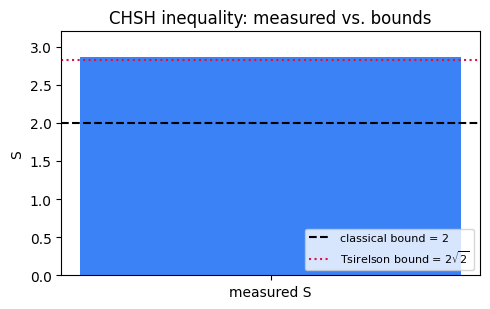

In [3]:
def bell_pair():
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    return qc

def chsh_circuit(theta_a, theta_b):
    # Bell pair, then measure qubit 0 in a basis rotated by theta_a and qubit 1 by theta_b.
    qc = bell_pair()
    qc.ry(-2 * theta_a, 0)
    qc.ry(-2 * theta_b, 1)
    qc.measure([0, 1], [0, 1])
    return qc

def correlator(theta_a, theta_b, shots=8192):
    qc = chsh_circuit(theta_a, theta_b)
    counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
    total = sum(counts.values())
    # +1 if the two bits agree, -1 if they disagree
    E = sum((+1 if k[0] == k[1] else -1) * v for k, v in counts.items()) / total
    return E

# Optimal CHSH measurement angles (radians)
a, ap = 0.0, np.pi / 4
b, bp = np.pi / 8, 3 * np.pi / 8

E_ab   = correlator(a, b)
E_abp  = correlator(a, bp)
E_apb  = correlator(ap, b)
E_apbp = correlator(ap, bp)

S = abs(E_ab - E_abp + E_apb + E_apbp)

print(f"E(a,b)   = {E_ab:+.3f}")
print(f"E(a,b')  = {E_abp:+.3f}")
print(f"E(a',b)  = {E_apb:+.3f}")
print(f"E(a',b') = {E_apbp:+.3f}")
print(f"\nCHSH S = {S:.3f}")
print(f"Classical (local realist) bound: 2.000")
print(f"Quantum (Tsirelson) bound:       {2*np.sqrt(2):.3f}")

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(["measured S"], [S], color="#3b82f6", width=0.4)
ax.axhline(2.0, color="black", linestyle="--", label="classical bound = 2")
ax.axhline(2*np.sqrt(2), color="crimson", linestyle=":", label=r"Tsirelson bound = $2\sqrt{2}$")
ax.set_ylim(0, 3.2)
ax.set_ylabel("S")
ax.legend(loc="lower right", fontsize=8)
ax.set_title("CHSH inequality: measured vs. bounds")
plt.tight_layout()
plt.savefig("chsh.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** $S$ comes out close to $2\sqrt{2}$, clearly above the classical bound of 2 — a genuine violation of local realism, reproduced numerically here and directly reproducible as a real experiment on an IBM QPU (this is a very common "first real experiment" for students with free-tier hardware time). On real hardware, gate noise typically pulls the measured $S$ down from $2.83$ to somewhere around $2.4$–$2.7$, but still comfortably above 2.

## 3. Multipartite entanglement: GHZ states

Entangling *N* qubits at once (a Greenberger–Horne–Zeilinger state) is a standard way hardware providers report qubit quality — the more qubits you can GHZ-entangle and still see a clean two-peak histogram, the better the chip's connectivity and coherence.


n=3: P(all-0 or all-1) on the noiseless simulator = 1.000  (ideal = 1.000; real hardware degrades with n)
n=5: P(all-0 or all-1) on the noiseless simulator = 1.000  (ideal = 1.000; real hardware degrades with n)
n=8: P(all-0 or all-1) on the noiseless simulator = 1.000  (ideal = 1.000; real hardware degrades with n)


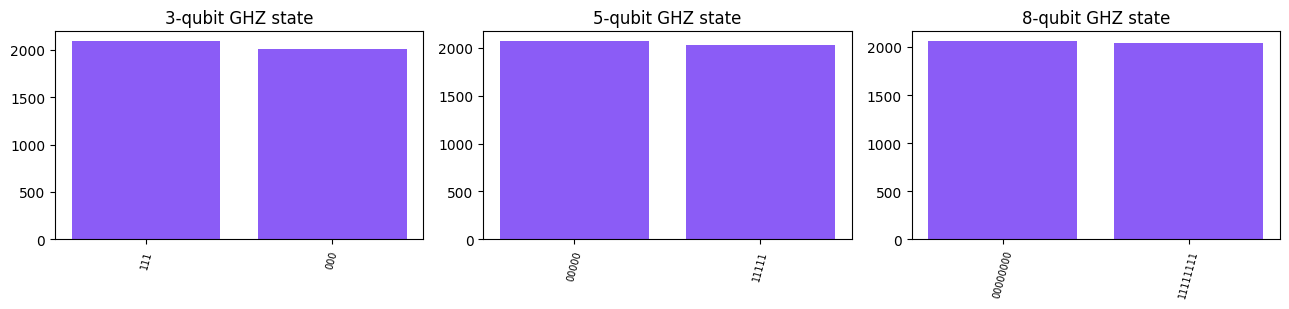

In [4]:
def ghz_counts(n_qubits, shots=4096):
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(0)
    for q in range(n_qubits - 1):
        qc.cx(q, q + 1)
    qc.measure(range(n_qubits), range(n_qubits))
    return sim.run(transpile(qc, sim), shots=shots).result().get_counts()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, n in zip(axes, [3, 5, 8]):
    counts = ghz_counts(n)
    all0 = "0" * n
    all1 = "1" * n
    frac_correct = (counts.get(all0, 0) + counts.get(all1, 0)) / sum(counts.values())
    print(f"n={n}: P(all-0 or all-1) on the noiseless simulator = {frac_correct:.3f}  "
          f"(ideal = 1.000; real hardware degrades with n)")
    top = dict(sorted(counts.items(), key=lambda kv: -kv[1])[:8])
    ax.bar(top.keys(), top.values(), color="#8b5cf6")
    ax.set_title(f"{n}-qubit GHZ state")
    ax.tick_params(axis='x', rotation=75, labelsize=7)
plt.tight_layout()
plt.savefig("ghz.png", dpi=110, bbox_inches="tight")
plt.show()


On the ideal simulator every case gives exactly two outcomes (all-0s and all-1s). On real hardware, `P(all-0 or all-1)` measurably drops as `n` grows — a real, publishable-style benchmark of how coherence and gate fidelity limit today's devices. Reproducing this curve on real IBM chips at increasing qubit counts is itself a legitimate (and popular) "basic science" hardware-characterization experiment.

## 4. A real physics calculation: VQE for a quantum spin model

This is the most "science paper"-like demo: the **variational quantum eigensolver (VQE)** finds the ground-state energy of a Hamiltonian by using a quantum circuit as a trial wavefunction and a classical optimizer to tune it — exactly the technique used in real VQE papers for molecules and materials, just with far more qubits there than we use here.

We use the **transverse-field Ising model (TFIM)** on 2 spins, a genuine condensed-matter Hamiltonian:

$$H(h) = -Z_0 Z_1 - h\,(X_0 + X_1)$$

As the transverse field $h$ is swept, the ground state crosses over from an aligned ("ferromagnetic") state at small $h$ to a field-polarized state at large $h$ — a finite-size echo of the real quantum phase transition that occurs at $h = 1$ in the infinite 1D TFIM chain, a textbook result in quantum magnetism.

We compute the ground energy two ways for each $h$: (a) **exact diagonalization** (brute-force linear algebra, our "ground truth"), and (b) **VQE** — a parameterized quantum circuit optimized purely by measuring expectation values, never by looking at the matrix. Real VQE result: the two should agree closely.


Max |exact - VQE| energy error across the sweep: 5.87e-05 Hartree-equivalent units


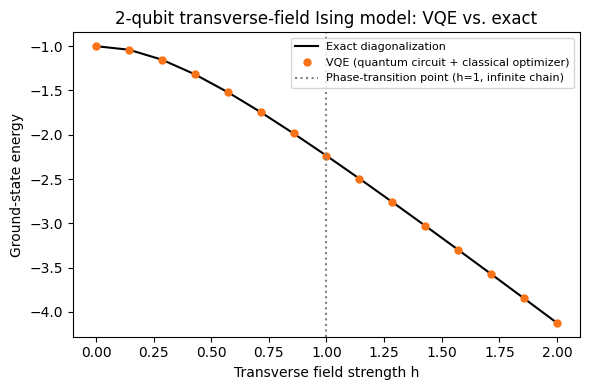

In [5]:
def tfim_hamiltonian(h):
    return SparsePauliOp.from_list([
        ("ZZ", -1.0),
        ("XI", -h),
        ("IX", -h),
    ])

def exact_ground_energy(h):
    H = tfim_hamiltonian(h).to_matrix()
    eigvals = np.linalg.eigvalsh(H)
    return eigvals[0]

def vqe_ansatz(params):
    qc = QuantumCircuit(2)
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)
    qc.cx(0, 1)
    qc.ry(params[2], 0)
    qc.ry(params[3], 1)
    return qc

estimator = StatevectorEstimator()

def vqe_ground_energy(h, n_restarts=4, seed=0):
    H = tfim_hamiltonian(h)
    rng = np.random.default_rng(seed)

    def cost(params):
        qc = vqe_ansatz(params)
        return estimator.run([(qc, H)]).result()[0].data.evs.item()

    best = np.inf
    for _ in range(n_restarts):
        x0 = rng.uniform(0, 2 * np.pi, size=4)
        res = minimize(cost, x0, method="COBYLA", options={"maxiter": 300})
        best = min(best, res.fun)
    return best

h_values = np.linspace(0.0, 2.0, 15)
exact_E = [exact_ground_energy(h) for h in h_values]
vqe_E   = [vqe_ground_energy(h) for h in h_values]

max_err = max(abs(e - v) for e, v in zip(exact_E, vqe_E))
print(f"Max |exact - VQE| energy error across the sweep: {max_err:.2e} Hartree-equivalent units")

plt.figure(figsize=(6, 4))
plt.plot(h_values, exact_E, "-", color="black", label="Exact diagonalization")
plt.plot(h_values, vqe_E, "o", color="#f97316", markersize=5, label="VQE (quantum circuit + classical optimizer)")
plt.axvline(1.0, color="gray", linestyle=":", label="Phase-transition point (h=1, infinite chain)")
plt.xlabel("Transverse field strength h")
plt.ylabel("Ground-state energy")
plt.title("2-qubit transverse-field Ising model: VQE vs. exact")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("vqe_tfim.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** VQE reproduces the exact ground-state energy curve to numerical precision, including the curvature change near $h=1$ where the finite-size system crosses over between the two competing ground states — the same qualitative feature that becomes a sharp quantum phase transition in the infinite chain. This is a real, if small, instance of exactly the calculation published VQE papers on quantum magnets and molecules perform — swapping in a different `SparsePauliOp` Hamiltonian (e.g. an H₂ qubit Hamiltonian from `qiskit-nature`) turns this into a quantum chemistry result with no other changes to the algorithm.

## 5. Running these same circuits on a real IBM quantum computer

Everything above used `AerSimulator` (noiseless, instant, free, offline). To run on **actual quantum hardware**, you only need to change how the circuit gets executed — the circuit-building code is identical. Outline (requires a free IBM Quantum account and API token from https://quantum.ibm.com/):

```python
# One-time setup (do this once, then it's saved locally):
# pip install qiskit-ibm-runtime
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="<your free API token from quantum.ibm.com>",
)

# In any later notebook:
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)   # picks a real, available QPU
print(backend.name, backend.num_qubits)

from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

isa_circuit = transpile(bell, backend, optimization_level=3)  # must match the chip's native gates/topology
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=4096)
print("Job ID:", job.job_id())        # jobs queue — often seconds to a few minutes on the Open Plan
result = job.result()
real_counts = result[0].data.meas.get_counts()
print(real_counts)                    # now expect a few % of '01'/'10' leakage from real noise
```

Practical notes for the free Open Plan (current as of this writing): roughly **10 minutes of QPU time per rolling 28 days** (with a 2026 promotion adding 180 bonus minutes over 12 months for existing users) — plenty for the small circuits above, since each one typically consumes well under a second of actual QPU time; the rest of the wait is a free queue. Keep circuits shallow (few two-qubit gates) and use `optimization_level=3` in `transpile` plus IBM's built-in error mitigation (`Sampler` options like `dynamical_decoupling`) to get usable results on today's noisy chips.


## 6. Other genuine "basic science" experiments within reach of free hardware time

All of these are real physics/CS results, small enough to fit comfortably in a free Open Plan allowance, and are standard "first hardware experiments" in the field:

- **Quantum teleportation** — teleport an unknown qubit state across an entangled pair using only classical communication + local operations; a direct demonstration of a foundational quantum-information protocol.
- **Deutsch–Jozsa / Bernstein–Vazirani / Grover's search** on 2–4 qubits — the smallest instances of provable quantum speedup algorithms; you can directly compare the number of queries needed vs. the best possible classical algorithm.
- **Quantum random number generation + statistical testing** — measure `H|0>` many times and run the results through a randomness test suite (e.g. a chi-squared test, or NIST's STS) to verify the outputs are consistent with true quantum randomness rather than a classical pseudo-random generator.
- **Device characterization** — pull a real backend's calibration data (T1/T2 coherence times, gate/readout error rates per qubit) via `backend.properties()` and plot how they vary across the chip; this is exactly the kind of characterization plot that appears in hardware papers.
- **Trotterized time evolution of a spin chain** — extend the VQE section's Hamiltonian to simulate *dynamics* (not just the ground state) by Trotter-decomposing $e^{-iHt}$ into gates, and watch magnetization oscillate/relax — a genuine quantum simulation result, the original motivating application Feynman proposed for quantum computers.
- **A 3-qubit repetition code** — encode one logical qubit into three physical qubits, deliberately flip one, and show the code detects and corrects it; the simplest real demonstration of quantum error correction.

Any of these can be dropped into this notebook using the same "build a circuit -> run on `AerSimulator` to develop -> swap in the real `backend` from Section 5" pattern.


## Sources

- [Plans overview — IBM Quantum Documentation](https://quantum.cloud.ibm.com/docs/en/guides/plans-overview)
- [New resources and hardware for Open Plan users (March 2026) — IBM Quantum](https://quantum.cloud.ibm.com/announcements/en/product-updates/2026-03-16-open-plan-news)
- [IBM Offers Special Promotion to Open Plan Users — Quantum Computing Report](https://quantumcomputingreport.com/ibm-offers-special-promotion-to-open-plan-users/)
